In [3]:
import yfinance as yf
#yf.download('2330.TW',start='2024-01-01',end='2024-06-01',auto_adjust=True)
tw2330 = yf.download('2330.TW',start='2024-01-01',end='2024-06-01',auto_adjust=True)
tw2303 = yf.download('2303.TW',start='2024-01-01',end='2024-06-01',auto_adjust=True)
tw2454 = yf.download('2454.TW',start='2024-01-01',end='2024-06-01',auto_adjust=True)
tw2317 = yf.download('2317.TW',start='2024-01-01',end='2024-06-01',auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [11]:
import pandas as pd
#下列作法先取出所有 Close 的資料。再從裡面選出 2317.TW。
#tw2330_s = tw2330['Close']['2330.TW']
#tw2303_s = tw2303['Close']['2303.TW']
#tw2454_s = tw2454['Close']['2454.TW']
#tw2317_s = tw2317['Close']['2317.TW']

#下列作法你可以直接用 tuple 指定完整的 key
tw2330_s = tw2330[('Close', '2330.TW')]
tw2303_s = tw2303[('Close', '2303.TW')]
tw2454_s = tw2454[('Close', '2454.TW')]
tw2317_s = tw2317[('Close', '2317.TW')]

df = pd.DataFrame({"台積電":tw2330_s,"聯電":tw2303_s,"聯發科":tw2454_s,"鴻海":tw2317_s})

In [12]:
 df_price = df.corr() #找出相關係數


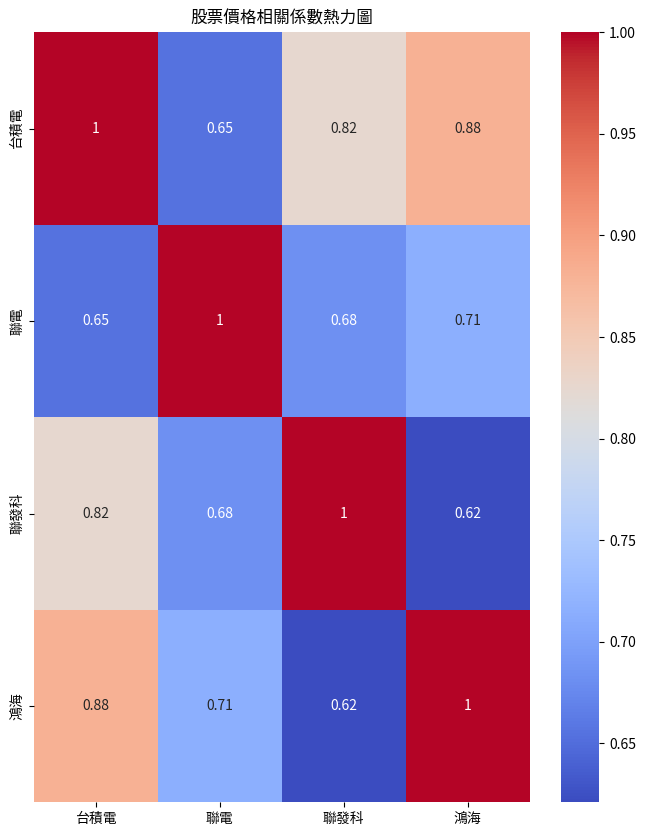

In [13]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager
import seaborn as sns
fontManager.addfont("ChineseFont.ttf")
mpl.rc('font', family="ChineseFont")

figure = plt.figure(figsize = (8, 10))
axes = figure.add_subplot(1,1,1)
sns.heatmap(df_price, annot=True, cmap='coolwarm',axes=axes)
# annot=True 在每個格子裡面直接顯示數值（annotation），方便直接看數字。
# cmap='coolwarm' 使用顏色漸層，coolwarm 是藍到紅的顏色表現，
axes.set_title("股票價格相關係數熱力圖")
plt.show()


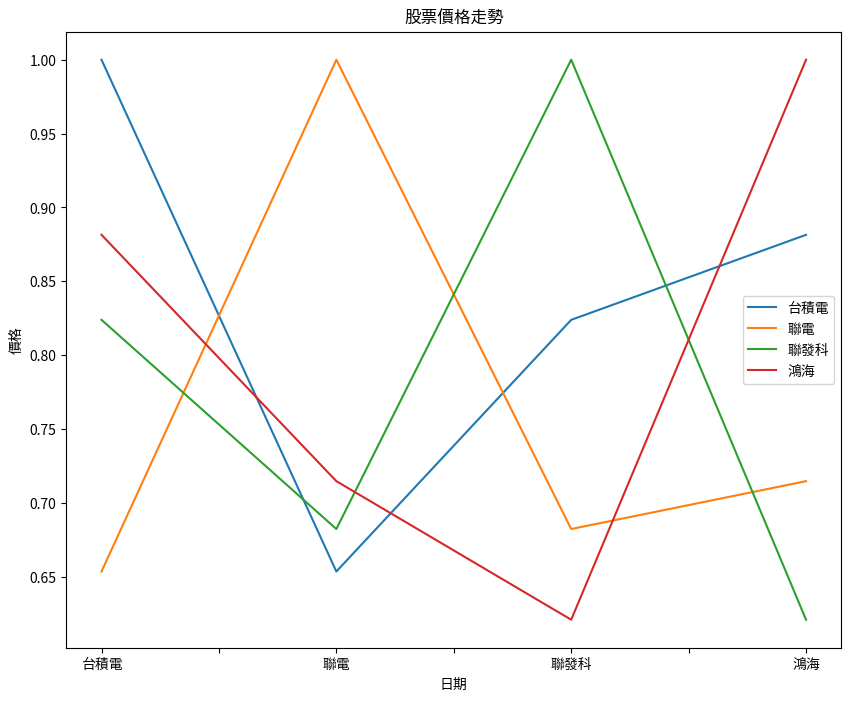

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.font_manager import fontManager

fontManager.addfont("ChineseFont.ttf")
mpl.rc('font', family="ChineseFont")

figure = plt.figure(figsize=(10, 8))
axes = figure.add_subplot(1,1,1)
df_price.plot(title='股票價格走勢', xlabel='日期', ylabel='價格',ax=axes)

plt.show()

In [8]:
percent_df = df_price.pct_change()
formatted = percent_df.map(lambda x: f"{x:.2%}" if pd.notnull(x) else "")
formatted

,台積電,聯電,聯發科,鴻海
台積電,,,,
聯電,-34.64%,53.00%,-17.18%,-18.92%
聯發科,26.06%,-31.76%,46.55%,-13.12%
鴻海,6.99%,4.75%,-37.90%,61.04%
